# Entrega Final: "Impacto en viajes del transporte público de Santiago"

## **Contexto**
El sistema de transporte público Red Metropolitana de Movilidad en Santiago es una red dinámica que debe adaptar su oferta para satisfacer las variaciones extremas de la demanda a lo largo de la semana. Nuestro proyecto se enfocará en analizar críticamente cómo esta adaptación de la oferta se plasma en los datos de la GTFS (General Transit Feed Specification) vigente y cómo impacta en diferentes áreas geográficas de la ciudad.

El desafío de la planificación no solo radica en cubrir la demanda máxima de los días laborales (peak), sino también en asignar recursos de manera eficiente durante los fines de semana, cuando los patrones de viaje cambian drásticamente (viajes recreativos, menor densidad de pasajeros, horarios de servicio más restringidos).

## **Motivación**
Como estudiantes de ciencia de datos, nos motiva aplicar técnicas de Análisis de Datos para evaluar la equidad y eficiencia del sistema de transporte en función del tiempo y el espacio. Específicamente, buscamos:

**1.- Cuantificar la Disparidad Semanal:** Mapear y cuantificar las diferencias en la oferta de transporte programada (frecuencias, cobertura de paradas) entre un día laboral y un fin de semana. Esto es crucial, ya que la diferencia en la calidad del servicio entre semana y fin de semana afecta la movilidad de los trabajadores con horarios no tradicionales y el acceso a servicios básicos.

**2.- Identificar la Vulnerabilidad Geográfica:** Analizar si las comunas periféricas o sectores específicos, que dependen fuertemente del bus, experimentan una reducción de servicio proporcionalmente mayor durante el fin de semana en comparación con las zonas centrales. Este análisis espacial tiene implicancias directas en la planificación urbana.

**3.- Generar decisiones operacionales:** Nuestro objetivo es generar visualizaciones y métricas concisas que puedan ser utilizadas por la DTPM o futuros estudios para optimizar la programación de itinerarios (frecuencias y distribución de flota) en función de la localización y el día, buscando la estabilidad y predictibilidad del servicio.

## 1. Cargar

In [2]:
import datetime

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/sample/2025-04-21_sample.csv")
df.head()

,tipo_transporte,tiene_bajada,tiempo_subida,tiempo_bajada,tiempo_etapa,comuna_subida,comuna_bajada,parada_subida,parada_bajada,dist_ruta_paraderos,dist_eucl_paraderos,x_subida,y_subida,x_bajada,y_bajada
0,BUS,1,2025-04-21 08:48:04,2025-04-21 08:50:39,155,RECOLETA,RECOLETA,T-4-19-SN-40,E-4-19-SN-55,853,825,347180,6301636,347201,6302489
1,BUS,1,2025-04-21 08:51:46,2025-04-21 08:54:58,192,RECOLETA,RECOLETA,E-4-19-SN-55,L-4-4-50-OP,1090,983,347200,6302473,346625,6303299
2,BUS,1,2025-04-21 15:34:28,2025-04-21 15:39:01,273,RECOLETA,RECOLETA,L-4-12-20-PO,E-4-295-OP-5,1127,959,346563,6303315,347168,6302522
3,METRO,0,2025-04-21 17:27:55,-,-,LAS CONDES,-,LOS DOMINICOS,-,-,-,356329,6302427,-,-
4,METRO,1,2025-04-21 09:12:16,2025-04-21 09:38:40,1584,ESTACION CENTRAL,SANTIAGO,ESTACION CENTRAL,PLAZA DE ARMAS,6240,3064,343933,6297455,346372,6299031


## 2. Limpieza

In [4]:
df.replace("-", np.nan, inplace=True)

# limpieza con comunas con tilde
comunas_con_tilde = {
    "SAN JOAQUIN": "SAN JOAQUÍN",
    "SAN RAMON": "SAN RAMÓN",
    "PENALOLEN": "PEÑALOLÉN",
    "NUNOA": "ÑUÑOA",
    "MAIPU": "MAIPÚ",
    "CONCHALI": "CONCHALÍ",
    "ESTACION CENTRAL": "ESTACIÓN CENTRAL"
}
def comunas_map(comuna):
    if comuna in comunas_con_tilde:
        return comunas_con_tilde[comuna]
    return comuna
df["comuna_subida"] = df["comuna_subida"].map(comunas_map)
df["comuna_bajada"] = df["comuna_bajada"].map(comunas_map)

In [5]:
transfo_df = df.copy()
transfo_df["tiempo_subida"] = pd.to_datetime(transfo_df["tiempo_subida"])
transfo_df["tiempo_bajada"] = pd.to_datetime(transfo_df["tiempo_bajada"])

transfo_df["tipo_transporte"] = transfo_df["tipo_transporte"].astype("category")
transfo_df["comuna_subida"] = transfo_df["comuna_subida"].astype("category")
transfo_df["comuna_bajada"] = transfo_df["comuna_bajada"].astype("category")
transfo_df["parada_bajada"] = transfo_df["parada_bajada"].astype("category")
transfo_df["parada_subida"] = transfo_df["parada_subida"].astype("category")

transfo_df["tiempo_etapa"] = transfo_df["tiempo_etapa"].astype(float)
transfo_df["x_bajada"] = transfo_df["x_bajada"].astype(float)
transfo_df["y_bajada"] = transfo_df["y_bajada"].astype(float)
transfo_df["x_subida"] = transfo_df["x_bajada"].astype(float)
transfo_df["y_subida"] = transfo_df["y_bajada"].astype(float)
transfo_df["dist_eucl_paraderos"] = transfo_df["dist_eucl_paraderos"].astype(float)
transfo_df["dist_ruta_paraderos"] = transfo_df["dist_ruta_paraderos"].astype(float)

transfo_df["tiene_bajada"] = transfo_df["tiene_bajada"].astype(bool)

transfo_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   tipo_transporte      5000 non-null   category      
 1   tiene_bajada         5000 non-null   bool          
 2   tiempo_subida        5000 non-null   datetime64[ns]
 3   tiempo_bajada        3795 non-null   datetime64[ns]
 4   tiempo_etapa         3795 non-null   float64       
 5   comuna_subida        4999 non-null   category      
 6   comuna_bajada        3786 non-null   category      
 7   parada_subida        4999 non-null   category      
 8   parada_bajada        3786 non-null   category      
 9   dist_ruta_paraderos  3795 non-null   float64       
 10  dist_eucl_paraderos  3795 non-null   float64       
 11  x_subida             3795 non-null   float64       
 12  y_subida             3795 non-null   float64       
 13  x_bajada             3795 non-nul

## 3. EDA

In [6]:
transfo_df.head()

,tipo_transporte,tiene_bajada,tiempo_subida,tiempo_bajada,tiempo_etapa,comuna_subida,comuna_bajada,parada_subida,parada_bajada,dist_ruta_paraderos,dist_eucl_paraderos,x_subida,y_subida,x_bajada,y_bajada
0,BUS,True,2025-04-21 08:48:04,2025-04-21 08:50:39,155.0,RECOLETA,RECOLETA,T-4-19-SN-40,E-4-19-SN-55,853.0,825.0,347201.0,6302489.0,347201.0,6302489.0
1,BUS,True,2025-04-21 08:51:46,2025-04-21 08:54:58,192.0,RECOLETA,RECOLETA,E-4-19-SN-55,L-4-4-50-OP,1090.0,983.0,346625.0,6303299.0,346625.0,6303299.0
2,BUS,True,2025-04-21 15:34:28,2025-04-21 15:39:01,273.0,RECOLETA,RECOLETA,L-4-12-20-PO,E-4-295-OP-5,1127.0,959.0,347168.0,6302522.0,347168.0,6302522.0
3,METRO,False,2025-04-21 17:27:55,NaT,NaN,LAS CONDES,NaN,LOS DOMINICOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,METRO,True,2025-04-21 09:12:16,2025-04-21 09:38:40,1584.0,ESTACIÓN CENTRAL,SANTIAGO,ESTACION CENTRAL,PLAZA DE ARMAS,6240.0,3064.0,346372.0,6299031.0,346372.0,6299031.0


In [7]:
def map_time_range(date):
    time = date.time()
    if (datetime.time(00, 00, 00) <= time) and (time <= datetime.time(5, 59, 59)):
        return "early"
    elif (datetime.time(6, 00, 00) <= time) and (time <= datetime.time(11, 59, 59)):
        return "morning"
    elif (datetime.time(12, 00, 00) <= time) and (time <= datetime.time(17, 59, 59)):
        return "afternoon"
    elif (datetime.time(18, 00, 00) <= time) and (time <= datetime.time(23, 59, 59)):
        return "night"

transfo_df["time_range"] = transfo_df["tiempo_subida"].map(map_time_range)

In [8]:
def map_time_type(date):
    time = date.time()
    if (datetime.time(6, 00, 00) <= time) and (time <= datetime.time(8, 59, 59)):
        return "rush_time-morning"
    elif (datetime.time(17, 00, 00) <= time) and (time <= datetime.time(19, 59, 59)):
        return "rush_time-night"
    else:
        return "normal"

transfo_df["time_type"] = transfo_df["tiempo_subida"].map(map_time_type)
transfo_df.head()

,tipo_transporte,tiene_bajada,tiempo_subida,tiempo_bajada,tiempo_etapa,comuna_subida,comuna_bajada,parada_subida,parada_bajada,dist_ruta_paraderos,dist_eucl_paraderos,x_subida,y_subida,x_bajada,y_bajada,time_range,time_type
0,BUS,True,2025-04-21 08:48:04,2025-04-21 08:50:39,155.0,RECOLETA,RECOLETA,T-4-19-SN-40,E-4-19-SN-55,853.0,825.0,347201.0,6302489.0,347201.0,6302489.0,morning,rush_time-morning
1,BUS,True,2025-04-21 08:51:46,2025-04-21 08:54:58,192.0,RECOLETA,RECOLETA,E-4-19-SN-55,L-4-4-50-OP,1090.0,983.0,346625.0,6303299.0,346625.0,6303299.0,morning,rush_time-morning
2,BUS,True,2025-04-21 15:34:28,2025-04-21 15:39:01,273.0,RECOLETA,RECOLETA,L-4-12-20-PO,E-4-295-OP-5,1127.0,959.0,347168.0,6302522.0,347168.0,6302522.0,afternoon,normal
3,METRO,False,2025-04-21 17:27:55,NaT,NaN,LAS CONDES,NaN,LOS DOMINICOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,afternoon,rush_time-night
4,METRO,True,2025-04-21 09:12:16,2025-04-21 09:38:40,1584.0,ESTACIÓN CENTRAL,SANTIAGO,ESTACION CENTRAL,PLAZA DE ARMAS,6240.0,3064.0,346372.0,6299031.0,346372.0,6299031.0,morning,normal


### ¿Cómo varía el tiempo de viaje respecto la hora (hora normal y hora de punta)?

hora de punta: 6-9am 5-8pm

In [9]:
df_has_bajada = transfo_df[transfo_df["tiene_bajada"] == True]
df_has_bajada.head()

,tipo_transporte,tiene_bajada,tiempo_subida,tiempo_bajada,tiempo_etapa,comuna_subida,comuna_bajada,parada_subida,parada_bajada,dist_ruta_paraderos,dist_eucl_paraderos,x_subida,y_subida,x_bajada,y_bajada,time_range,time_type
0,BUS,True,2025-04-21 08:48:04,2025-04-21 08:50:39,155.0,RECOLETA,RECOLETA,T-4-19-SN-40,E-4-19-SN-55,853.0,825.0,347201.0,6302489.0,347201.0,6302489.0,morning,rush_time-morning
1,BUS,True,2025-04-21 08:51:46,2025-04-21 08:54:58,192.0,RECOLETA,RECOLETA,E-4-19-SN-55,L-4-4-50-OP,1090.0,983.0,346625.0,6303299.0,346625.0,6303299.0,morning,rush_time-morning
2,BUS,True,2025-04-21 15:34:28,2025-04-21 15:39:01,273.0,RECOLETA,RECOLETA,L-4-12-20-PO,E-4-295-OP-5,1127.0,959.0,347168.0,6302522.0,347168.0,6302522.0,afternoon,normal
4,METRO,True,2025-04-21 09:12:16,2025-04-21 09:38:40,1584.0,ESTACIÓN CENTRAL,SANTIAGO,ESTACION CENTRAL,PLAZA DE ARMAS,6240.0,3064.0,346372.0,6299031.0,346372.0,6299031.0,morning,normal
5,METRO,True,2025-04-21 10:49:35,2025-04-21 11:17:20,1665.0,SANTIAGO,LA FLORIDA,PLAZA DE ARMAS,BELLAVISTA DE LA FLORIDA,11630.0,10307.0,351430.0,6289929.0,351430.0,6289929.0,morning,normal


In [10]:
df_has_bajada.groupby("time_type").agg({"tiempo_etapa": "mean"})

,tiempo_etapa
time_type,
normal,1167.508742
rush_time-morning,1340.028490
rush_time-night,1344.335397


In [11]:
df_has_bajada.groupby(["time_type", "tipo_transporte"], observed=True).agg({"tiempo_etapa": "mean"})

tiempo_etapa
time_type         tipo_transporte              
normal            BUS                902.424514
                  METRO             1381.771305
                  METROTREN          881.147059
                  ZP                1086.783217
rush_time-morning BUS               1041.310440
                  METRO             1545.280265
                  METROTREN          880.500000
                  ZP                1230.300000
rush_time-night   BUS               1222.069767
                  METRO             1454.527629
                  METROTREN          829.375000
                  ZP                1133.262626

### ¿Cómo varían la comuna subida y comuna bajada respecto la hora?
(cómo circulan las gentes.)

hora: 
early [0-6)
morning [6-12)
afternoon [12-18)
night [18-24)


In [12]:
pv_subida = pd.pivot_table(data=df_has_bajada, index='comuna_subida', columns="time_range", aggfunc="size", observed=False)
pv_bajada = pd.pivot_table(data=df_has_bajada, index='comuna_bajada', columns="time_range", aggfunc="size", observed=False)

In [13]:
pv_subida.sort_values(by="early", ascending=False).head()[["early"]]

time_range,early
comuna_subida,
SANTIAGO,3
CERRILLOS,2
HUECHURABA,2
MAIPÚ,2
LAS CONDES,2


In [14]:
pv_bajada.sort_values(by="early", ascending=False).head()[["early"]]

time_range,early
comuna_bajada,
LAS CONDES,4
HUECHURABA,2
ESTACIÓN CENTRAL,2
MAIPÚ,2
SANTIAGO,2


In [15]:
pv_subida.sort_values(by="morning", ascending=False).head()[["morning"]]

time_range,morning
comuna_subida,
SANTIAGO,171
LAS CONDES,129
MAIPÚ,125
PROVIDENCIA,110
ÑUÑOA,109


In [16]:
pv_bajada.sort_values(by="morning", ascending=False).head()[["morning"]]

time_range,morning
comuna_bajada,
SANTIAGO,301
PROVIDENCIA,217
LAS CONDES,205
ÑUÑOA,85
ESTACIÓN CENTRAL,80


In [17]:
pv_subida.sort_values(by="afternoon", ascending=False).head()[["afternoon"]]

time_range,afternoon
comuna_subida,
SANTIAGO,216
PROVIDENCIA,147
LAS CONDES,135
ÑUÑOA,93
MAIPÚ,65


In [18]:
pv_bajada.sort_values(by="afternoon", ascending=False).head()[["afternoon"]]

time_range,afternoon
comuna_bajada,
SANTIAGO,165
LAS CONDES,134
PROVIDENCIA,122
ÑUÑOA,108
MAIPÚ,81


In [19]:
pv_subida.sort_values(by="night", ascending=False).head()[["night"]]

time_range,night
comuna_subida,
SANTIAGO,158
PROVIDENCIA,149
LAS CONDES,124
ÑUÑOA,62
MAIPÚ,41


In [20]:
pv_bajada.sort_values(by="night", ascending=False).head()[["night"]]

time_range,night
comuna_bajada,
SANTIAGO,99
ÑUÑOA,80
PROVIDENCIA,74
LAS CONDES,73
MAIPÚ,59


#### Graficar

heatmap con mapa de santiago

In [21]:
import geopandas as gpd


In [22]:
shp_comunas = gpd.read_file("../data/comunas/comunas.shp").to_crs(epsg=4326)
comunas_santiago = shp_comunas[shp_comunas["Region"] == "Región Metropolitana de Santiago"].copy()
comunas_santiago["Comuna"] = comunas_santiago["Comuna"].str.upper()

### Veamos en que comunas se suben mas personas:

In [23]:
shp_con_dato_subida = pd.merge(comunas_santiago, pv_subida, how="outer", left_on="Comuna", right_index=True)
shp_con_dato_subida.fillna(0.0, inplace=True)

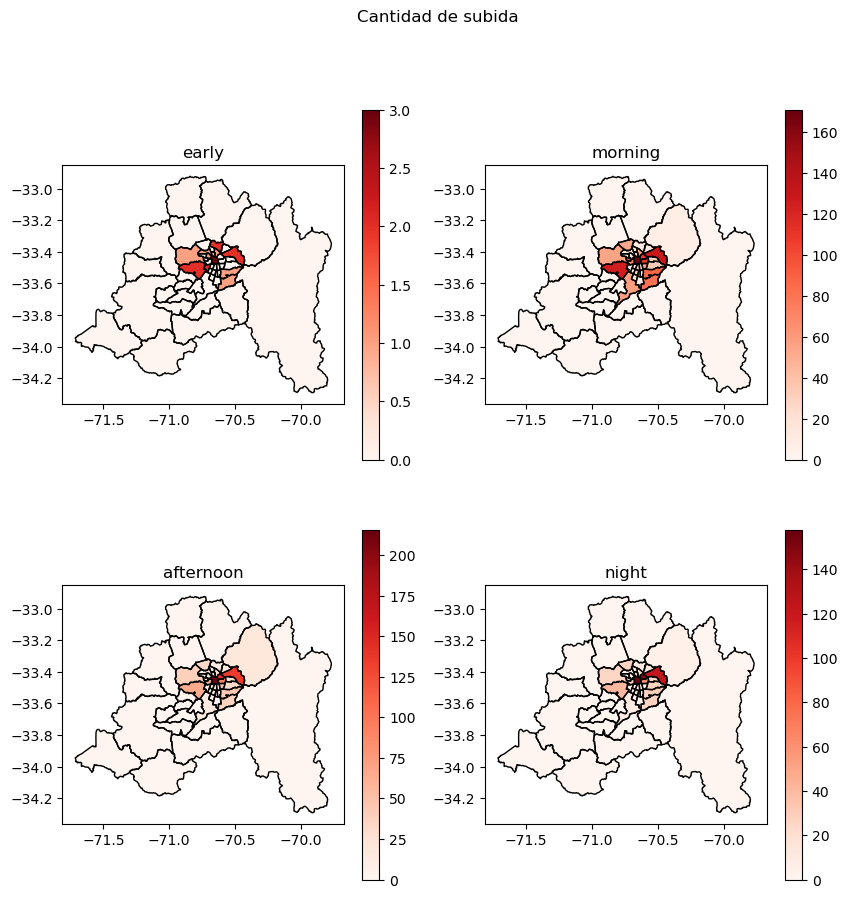

In [24]:
fig = plt.figure(figsize=(10,10))
fig.suptitle("Cantidad de subida")

for i, time in enumerate(["early", "morning", "afternoon", "night"], 1):
    ax = fig.add_subplot(220+i)
    shp_con_dato_subida.boundary.plot(ax=ax, color="black", linewidth=1)
    shp_con_dato_subida.plot(ax=ax, column=time, cmap='Reds', legend=True)
    ax.set_title(time)

### Veamos en que comunas se bajan más:

In [25]:
shp_con_dato_bajada = pd.merge(comunas_santiago, pv_bajada, how="outer", left_on="Comuna", right_index=True)
shp_con_dato_bajada.fillna(0.0, inplace=True)

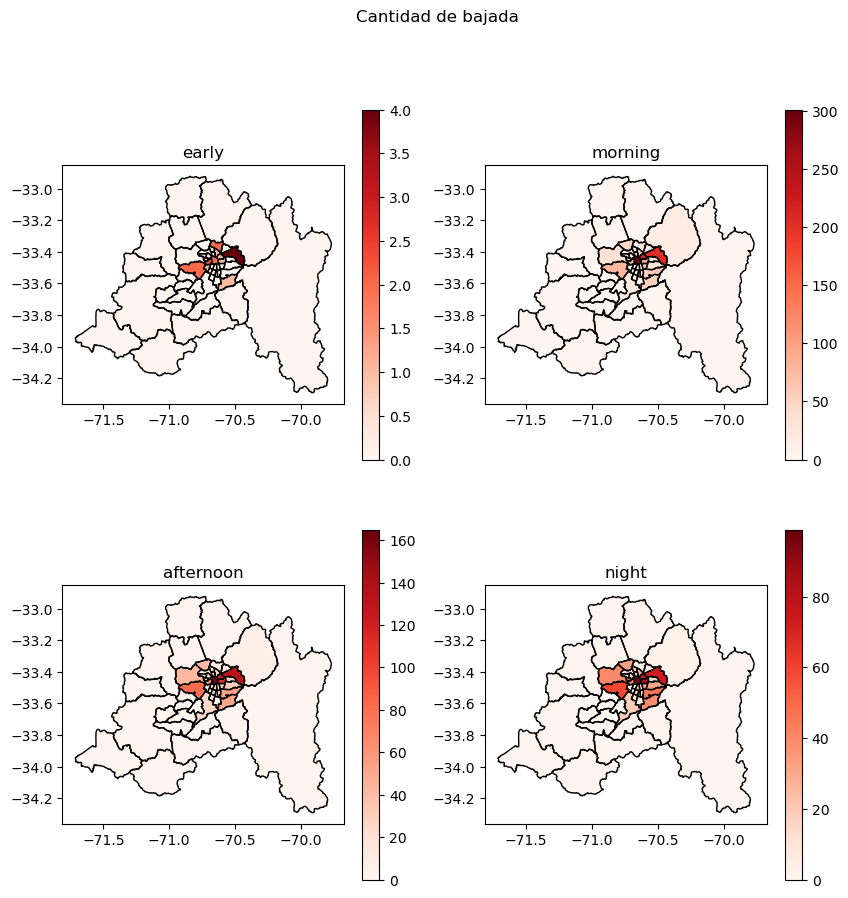

In [26]:
fig = plt.figure(figsize=(10,10))
fig.suptitle("Cantidad de bajada")

for i, time in enumerate(["early", "morning", "afternoon", "night"], 1):
    ax = fig.add_subplot(220+i)
    shp_con_dato_bajada.boundary.plot(ax=ax, color="black", linewidth=1)
    shp_con_dato_bajada.plot(ax=ax, column=time, cmap='Reds', legend=True)
    ax.set_title(time)

Estos cuatro mapas nos permiten entender cómo se comporta la demanda de transporte público en Santiago a lo largo de un día. El formato elegido es el de mapa coroplético, que utiliza la intensidad del color (donde el rojo más oscuro significa mayor "Cantidad de subida" de pasajeros) para representar datos directamente sobre las comunas geográficas. Como pueden ver, **la principal conclusión es que la demanda está fuertemente centralizada en todos los rangos horarios.** Aunque las escalas cambian a lo largo del día, las comunas centrales consistentemente muestran el mayor número de subidas. Este formato de mapa es ideal porque visualiza de inmediato dónde están las horas pico, permitiéndonos identificar con precisión las zonas geográficas clave para optimizar la asignación de recursos.

### Ahora veamos cuanto tiempo viaja la mayoria de pasajeros:

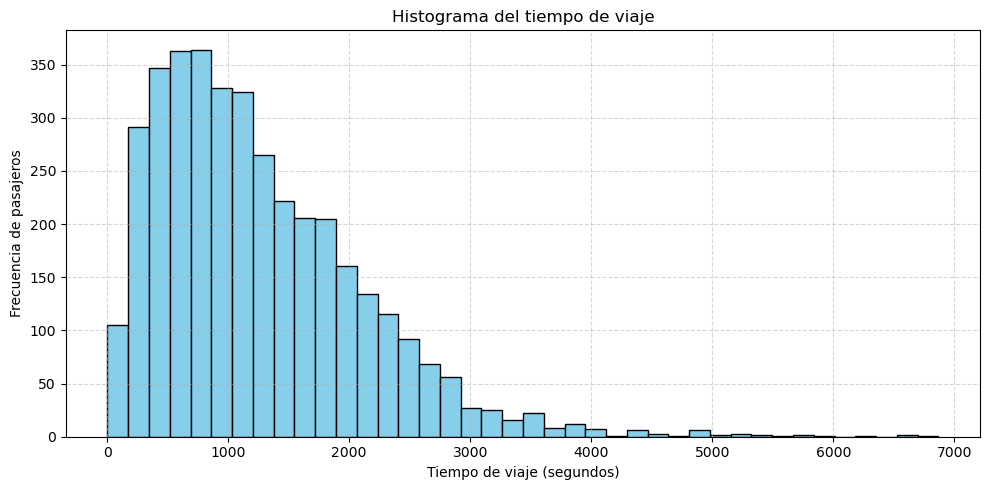

In [27]:


plt.figure(figsize=(10,5))
plt.hist(df_has_bajada['tiempo_etapa'].dropna(), bins=40, color='skyblue', edgecolor='black')
plt.title('Histograma del tiempo de viaje')
plt.xlabel('Tiempo de viaje (segundos)')
plt.ylabel('Frecuencia de pasajeros')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Este gráfico es un histograma que visualiza la Distribución de la Frecuencia de todos los Tiempos de Viaje en el conjunto de datos, sin segmentar por hora o transporte.

​El formato de histograma es el más adecuado porque muestra cómo se distribuyen los datos a lo largo del eje del tiempo, permitiendo identificar la forma, el pico y el sesgo de la duración de todos los viajes. **La principal conclusión es que la distribución está fuertemente sesgada a la izquierda, con un pico de frecuencia (la moda) muy claro. Al observar el pico, se evidencia que la gran mayoría de los viajes dura menos de 1,500 segundos (25 minutos), siendo la duración más común aquella alrededor de los 1,000 segundos** (aproximadamente 16-17 minutos), y los viajes de más de 4,000 segundos son muy raros.

### Tambien podemos comparar estos mismos tiempos y frecuencia entre cada transporte:

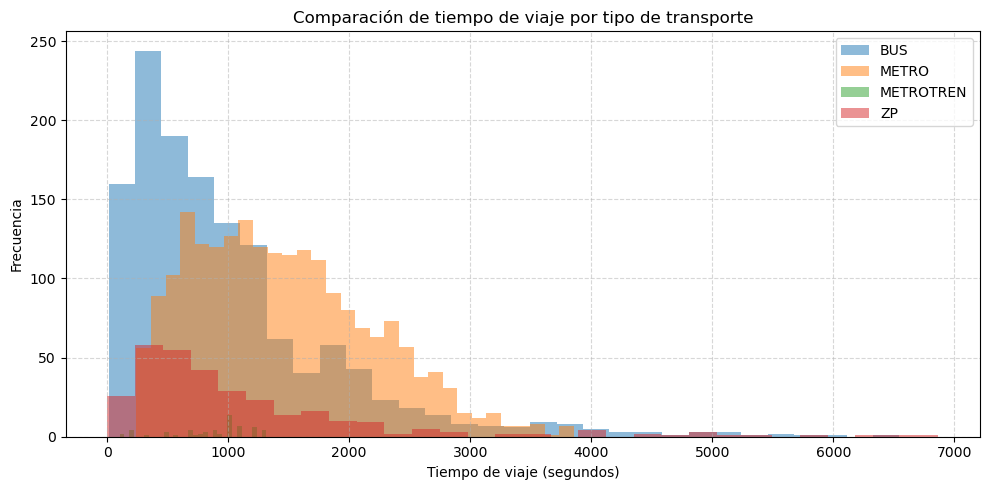

In [28]:
plt.figure(figsize=(10,5))
for tipo in df_has_bajada['tipo_transporte'].dropna().unique():
    subset = df_has_bajada[df_has_bajada['tipo_transporte'] == tipo]['tiempo_etapa'].dropna()
    plt.hist(subset, bins=30, alpha=0.5, label=tipo)

plt.title('Comparación de tiempo de viaje por tipo de transporte')
plt.xlabel('Tiempo de viaje (segundos)')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



Este gráfico utiliza un histograma superpuesto para comparar la distribución de los tiempos de viaje entre los distintos modos de transporte (BUS y METRO, principalmente). La frecuencia alta del BUS en el lado izquierdo (viajes cortos) y la distribución más extendida y larga del METRO hacia la derecha, **muestran claramente la función de cada uno: el bus maneja el volumen de viajes cortos y locales, mientras que el metro es esencial para los trayectos más largos.** El formato de histograma es el más adecuado porque permite ver de un vistazo cómo la forma de la distribución (viajes cortos versus largos) difiere significativamente entre los tipos de transporte, revelando su rol operativo en el sistema.


### Tambien queremos ver mejor los horarios en que hay mas personas:

/var/folders/2m/78v6gw9x19x1vhlbn1gn2pp40000gn/T/ipykernel_2528/1238033252.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_has_bajada['hora'] = df_has_bajada['tiempo_subida'].dt.hour


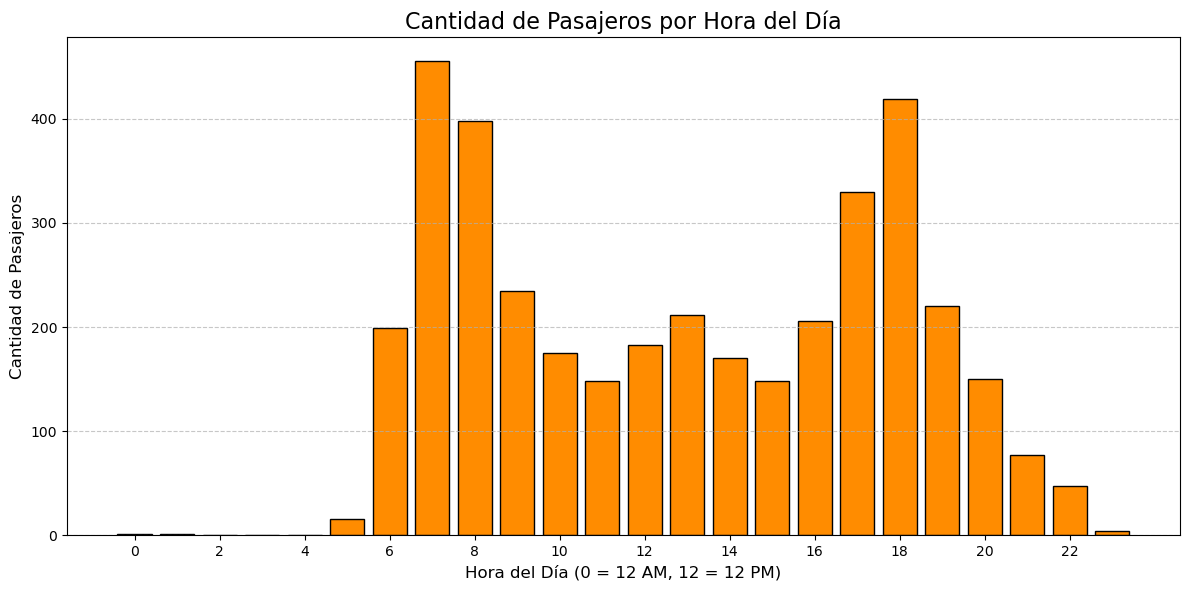

In [29]:
df_has_bajada['hora'] = df_has_bajada['tiempo_subida'].dt.hour

pasajeros_por_hora = df_has_bajada.groupby('hora').size().reset_index(name='cantidad_pasajeros')

# CODIGO SUGERIDO POR IA, PROMPT: "Como puedo asegurar que todas las 24 horas estén presentes"
# Esto garantiza que el gráfico no tenga saltos si no hubo viajes a una hora específica.
# Crea un índice de 0 a 23 y rellena las horas sin datos con 0.
pasajeros_por_hora = pasajeros_por_hora.set_index('hora').reindex(range(24), fill_value=0).reset_index()
# FIN CODIO IA

plt.figure(figsize=(12, 6))
plt.bar(
    pasajeros_por_hora['hora'], 
    pasajeros_por_hora['cantidad_pasajeros'], 
    color='darkorange',
    edgecolor='black'
)

plt.title('Cantidad de Pasajeros por Hora del Día', fontsize=16)
plt.xlabel('Hora del Día (0 = 12 AM, 12 = 12 PM)', fontsize=12)
plt.ylabel('Cantidad de Pasajeros', fontsize=12)

plt.xticks(range(0, 24, 2))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

El gráfico utiliza un diagrama de barras para visualizar la Cantidad de Pasajeros por Hora del Día en Santiago. El formato de barras es el más adecuado porque muestra de manera directa y clara la frecuencia o el conteo de viajes para cada una de las 24 horas del día. **La principal conclusión que presenta el gráfico es la clara identificación de los períodos pico o de máxima demanda:** se observa un aumento significativo de pasajeros durante la mañana (aproximadamente entre las 7 y 9 AM) y un segundo pico más alto durante la tarde (aproximadamente entre las 5 y 7 PM), revelando los horarios de mayor congestión y necesidad de recursos.

### Incluso podemos revisar en que horarios toman mas tiempo los viajes:

/var/folders/2m/78v6gw9x19x1vhlbn1gn2pp40000gn/T/ipykernel_2528/60329942.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_has_bajada['hora'] = df_has_bajada['hora'].astype('category')


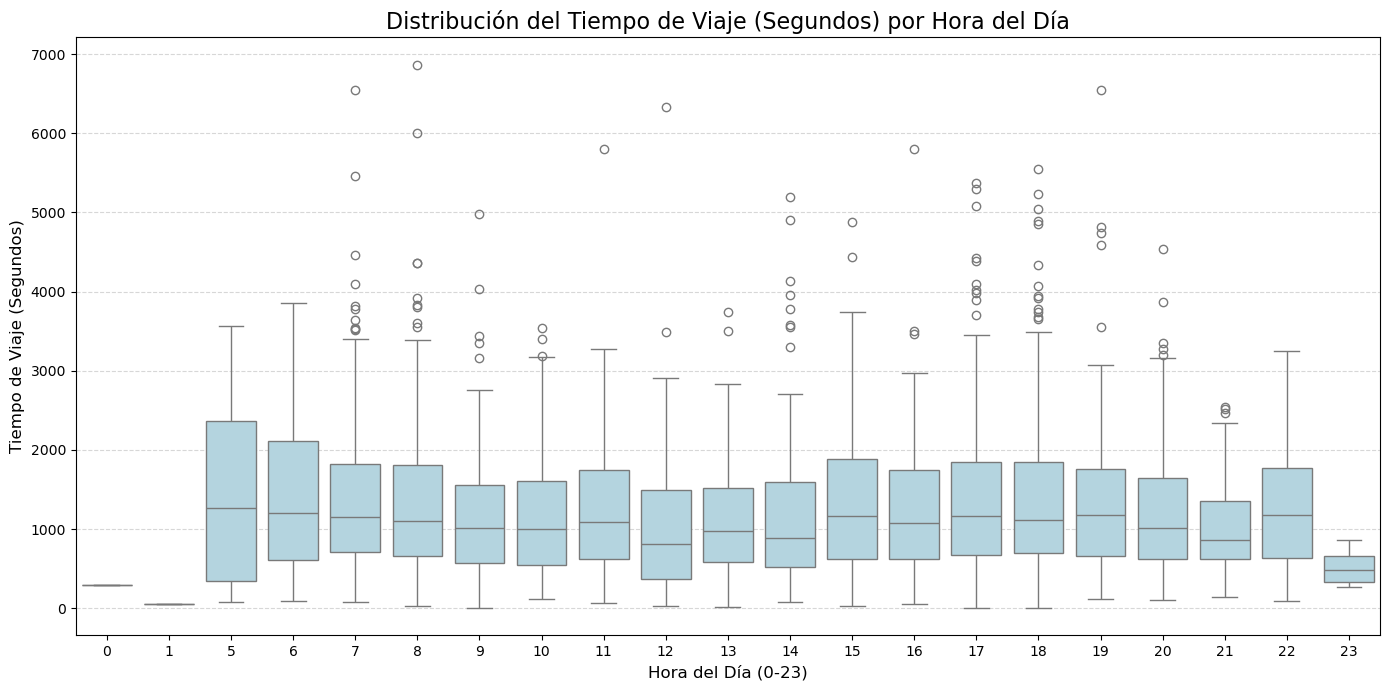

In [30]:
df_has_bajada['hora'] = df_has_bajada['hora'].astype('category')
plt.figure(figsize=(14, 7))

sns.boxplot(x='hora', y='tiempo_etapa', data=df_has_bajada, color='lightblue')

plt.title('Distribución del Tiempo de Viaje (Segundos) por Hora del Día', fontsize=16)
plt.xlabel('Hora del Día (0-23)', fontsize=12)
plt.ylabel('Tiempo de Viaje (Segundos)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Este gráfico utiliza un diagrama de caja y bigotes (Box Plot) para mostrar la Distribución del Tiempo de Viaje para cada hora del día. El formato de Box Plot es la elección más efectiva porque, en lugar de mostrar solo el promedio, visualiza de forma concisa la variabilidad del tiempo de viaje en cada hora. Podemos identificar fácilmente la mediana (la línea dentro de la caja) y la dispersión de los datos (el tamaño de la caja y los bigotes). **La principal conclusión es cómo se incrementa o estabiliza la duración típica del viaje (la mediana) durante las horas pico de la mañana y la tarde, y cuánta incertidumbre hay en el tiempo de viaje, representada por la altura de las cajas.**

### Ademas, podemos verificar de donde vienen la mayoria de datos de transporte:

/var/folders/2m/78v6gw9x19x1vhlbn1gn2pp40000gn/T/ipykernel_2528/2113336938.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pasajeros_por_transporte = df_has_bajada.groupby('tipo_transporte').size().reset_index(name='cantidad_pasajeros')


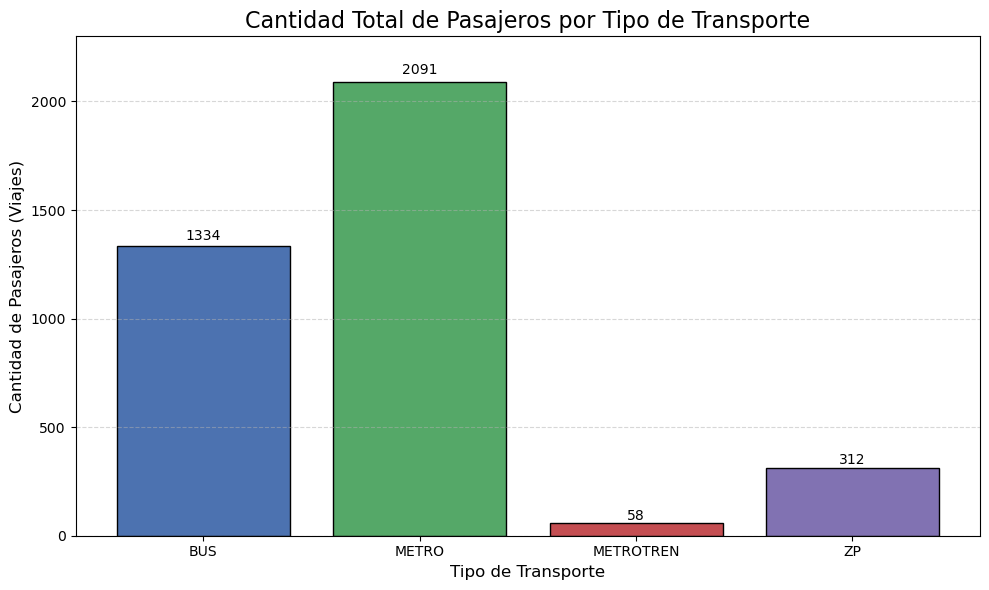

In [31]:
pasajeros_por_transporte = df_has_bajada.groupby('tipo_transporte').size().reset_index(name='cantidad_pasajeros')

plt.figure(figsize=(10, 6))

barras = plt.bar(
    pasajeros_por_transporte['tipo_transporte'], 
    pasajeros_por_transporte['cantidad_pasajeros'], 
    color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'],  # Codigo de colores sugerido por IA, prompt: "Que colores puedo usar en grafico python? Como los anoto?"
    edgecolor='black'
)
for bar in barras:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (yval * 0.01), 
             int(yval), ha='center', va='bottom', fontsize=10)

plt.title('Cantidad Total de Pasajeros por Tipo de Transporte', fontsize=16)
plt.xlabel('Tipo de Transporte', fontsize=12)
plt.ylabel('Cantidad de Pasajeros (Viajes)', fontsize=12)

# Quitar el límite superior del eje Y y hacer que el eje Y comience en 0 
plt.ylim(bottom=0, top=pasajeros_por_transporte['cantidad_pasajeros'].max() * 1.1)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### _Claramente podemos ver que la mayoria de nuestros datos provienen de transportes como metro o bus_

## 4. Responder las preguntas

### 4.0 ML para predecir tiempo de viaje
Ahora creamos un modelo ML para predecir el tiempo de viaje basado en las características disponibles.


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor

# Modelo de regresion lineal como baseline

La funcion de la regresion lineal está dada por: 
$$\text{tiempo\_etapa} \approx \beta_0 + \beta_1\text{dist\_ruta} + \beta_2\text{dist\_eucl} + \beta_3\text{es\_metro} + \beta_4\text{es\_punta} + \dots$$

In [33]:
df_model = transfo_df.dropna(subset=['tiempo_etapa']).copy()
features = [
    'dist_ruta_paraderos',  
    'dist_eucl_paraderos',  
    'tipo_transporte',      
    'time_type',             
    'comuna_subida'          
]

X = df_model[features]
y = df_model['tiempo_etapa']

#Hacemos One-Hot Encoding
X = pd.get_dummies(X, columns=['tipo_transporte', 'time_type', 'comuna_subida'], drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Resultados del Modelo:")
print(f"RMSE : {rmse:.2f}")
print(f"R2 : {r2:.4f}")

Resultados del Modelo:
RMSE : 460.14
R2 : 0.6804


###  VISUALIZACIÓN DE RESULTADOS


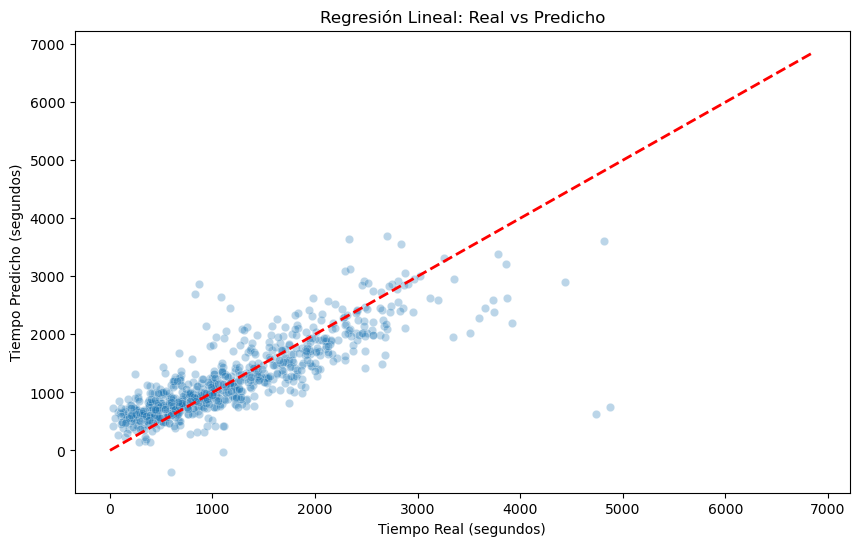

In [34]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Línea de perfección
plt.xlabel('Tiempo Real (segundos)')
plt.ylabel('Tiempo Predicho (segundos)')
plt.title('Regresión Lineal: Real vs Predicho')
plt.show()

###  MODELO RANDOM FOREST

In [36]:
#hacemos lo mismo que el anterior modelo
df_model = transfo_df.dropna(subset=['tiempo_etapa']).copy()
features = [
    'dist_ruta_paraderos',
    'dist_eucl_paraderos',
    'tipo_transporte',
    'time_type',
    'comuna_subida'
]

X = df_model[features]
y = df_model['tiempo_etapa']

X = pd.get_dummies(X, columns=['tipo_transporte', 'time_type', 'comuna_subida'], drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ENTRENAMIENTO (RANDOM FOREST)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Resultados Random Forest:")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.4f}")


Resultados Random Forest:
RMSE: 395.61
R2: 0.7638


Vemos que RMSE es 395.61 , mejor predicción que el RMSE de la reggresion lineal 460.14


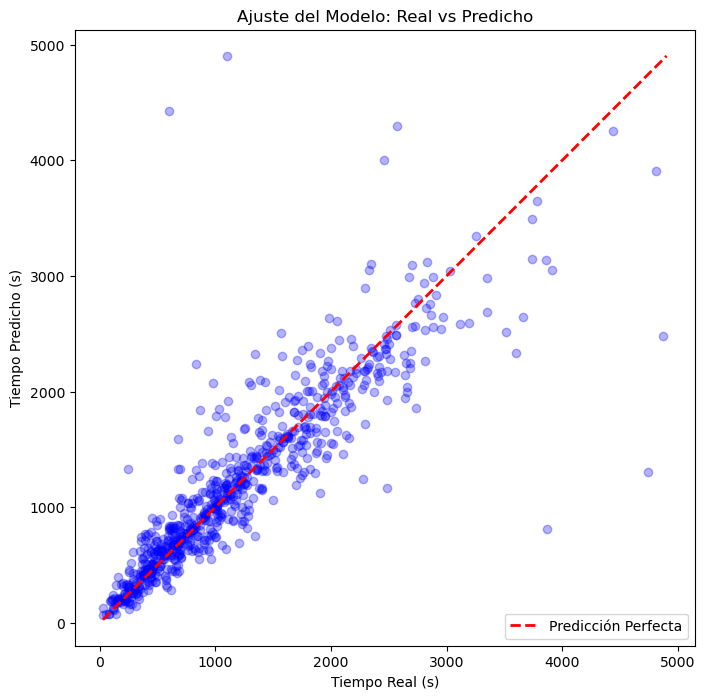

In [37]:
plt.figure(figsize=(8, 8))

# Gráfico de dispersión
plt.scatter(y_test, y_pred, alpha=0.3, color='blue')

max_val = max(y_test.max(), y_pred.max())
min_val = min(y_test.min(), y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Predicción Perfecta')

plt.xlabel('Tiempo Real (s)')
plt.ylabel('Tiempo Predicho (s)')
plt.title('Ajuste del Modelo: Real vs Predicho')
plt.legend()
plt.axis('equal') 
plt.show()

In [ ]:
target_col = 'tiempo_etapa' 
df_model = transfo_df.dropna(subset=[target_col]).copy()

features = [
    'dist_ruta_paraderos',
    'dist_eucl_paraderos',
    'tipo_transporte',
    'time_type',
    'comuna_subida'
]

X = df_model[features]
y = df_model[target_col]


X = pd.get_dummies(X, columns=['tipo_transporte', 'time_type', 'comuna_subida'], drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#ENTRENAMIENTO (GRADIENT BOOSTING)
gb_model = GradientBoostingRegressor(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=5,        
    random_state=42
)

gb_model.fit(X_train, y_train)
y_pred = gb_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Resultados Gradient Boosting:")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.4f}")


Resultados Gradient Boosting:
RMSE: 342.95
R2: 0.8033


### Visualizacion

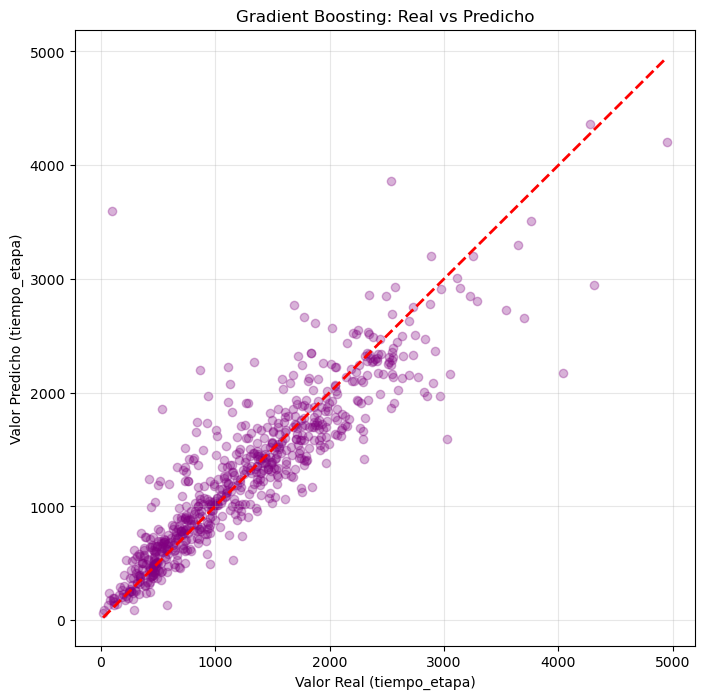

In [76]:

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.3, color='purple')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

plt.xlabel(f'Valor Real ({target_col})')
plt.ylabel(f'Valor Predicho ({target_col})')
plt.title(f'Gradient Boosting: Real vs Predicho')
plt.grid(True, alpha=0.3)
plt.show()

### 4.1 ML con Datos Meteorologicos

Ahora estudiamos el efecto de los datos meteorologicos en la cantidad de pasajeros, por horas.

In [39]:
import requests
import pandas as pd
import numpy as np
import seaborn as sns

#### 4.1.1. Datos Meteorologicos

Usamos el API de [open-meteo](https://open-meteo.com/) para descargar los datos meteorologicos.

In [40]:
fields = ["pm2_5", "apparent_temperature", "relative_humidity_2m"]
start_date = "2025-04-21"
end_date = "2025-04-27"

air_api = f"https://air-quality-api.open-meteo.com/v1/air-quality?latitude=-33.45694&longitude=-70.64827&start_date={start_date}&end_date={end_date}&hourly={fields[0]}&timezone=America/Santiago"
meteo_json_api = f"https://archive-api.open-meteo.com/v1/archive?latitude=-33.45694&longitude=-70.64827&start_date={start_date}&end_date={end_date}&hourly={",".join(fields[1:])}&timezone=America/Santiago"

air_quality_json = requests.get(air_api).json()
meteo_json = requests.get(meteo_json_api).json()

In [41]:
# Guardar los datos meteos
import json

with open("../data/meteo/air_quality.json", "w", encoding="utf-8") as f:
    json.dump(air_quality_json, f, indent=4)
with open("../data/meteo/meteo.json", "w", encoding="utf-8") as f:
    json.dump(meteo_json, f, indent=4)

In [42]:
meteo_df = pd.concat(
    [
        pd.json_normalize(air_quality_json["hourly"], record_path=["time"]),
        pd.json_normalize(air_quality_json["hourly"], record_path=["pm2_5"]),
        *[pd.json_normalize(meteo_json["hourly"], record_path=[field]) for field in fields[1:]]
    ], axis=1
)
meteo_df.columns = ["time", *fields]
meteo_df.tail()

,time,pm2_5,apparent_temperature,relative_humidity_2m
163,2025-04-27T19:00,42.6,19.5,58
164,2025-04-27T20:00,58.2,18.1,63
165,2025-04-27T21:00,69.6,17.9,62
166,2025-04-27T22:00,70.5,16.7,65
167,2025-04-27T23:00,71.7,16.1,67


In [43]:
meteo_df["time"] = pd.to_datetime(meteo_df["time"])
meteo_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   time                  168 non-null    datetime64[ns]
 1   pm2_5                 168 non-null    float64       
 2   apparent_temperature  168 non-null    float64       
 3   relative_humidity_2m  168 non-null    int64         
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 5.4 KB


In [44]:
meteo_df.tail()

,time,pm2_5,apparent_temperature,relative_humidity_2m
163,2025-04-27 19:00:00,42.6,19.5,58
164,2025-04-27 20:00:00,58.2,18.1,63
165,2025-04-27 21:00:00,69.6,17.9,62
166,2025-04-27 22:00:00,70.5,16.7,65
167,2025-04-27 23:00:00,71.7,16.1,67


#### 4.1.2. Datos sobre Cantidad de Pasajeros

Cargamos el dataframe procesado usando el scrit [datos_por_hora.ipynb](./script/datos_por_hora.ipynb).

In [45]:
pasaj_df = pd.read_csv("../data/pasajeros_por_hora.csv")
pasaj_df.tail()

,hora,2025-04-21,2025-04-22,2025-04-23,2025-04-24,2025-04-25,2025-04-26,2025-04-27
19,19,304,326,320,335,272,339,409
20,20,200,203,186,206,202,256,369
21,21,101,139,144,134,145,198,229
22,22,77,66,65,87,93,120,113
23,23,9,11,14,17,19,23,10


In [46]:
pasajes = []
for col in pasaj_df.columns[1:]:
    pasajes.extend(pasaj_df[col].values.tolist())
pasajs = np.array(pasajes)

In [47]:
pasajs_mean = pasajs.mean()

#### 4.1.3. Dataframe Completo

Armamos un dataframe que contiene los datos anteriores, para poder hacer los siguiente analisis.

In [48]:
full_df = meteo_df.copy()
full_df["pasaj"] = pasajs
full_df["hora"] = full_df["time"].dt.hour

full_df.tail()

,time,pm2_5,apparent_temperature,relative_humidity_2m,pasaj,hora
163,2025-04-27 19:00:00,42.6,19.5,58,409,19
164,2025-04-27 20:00:00,58.2,18.1,63,369,20
165,2025-04-27 21:00:00,69.6,17.9,62,229,21
166,2025-04-27 22:00:00,70.5,16.7,65,113,22
167,2025-04-27 23:00:00,71.7,16.1,67,10,23


#### 4.1.4. Explorar sobre los datos

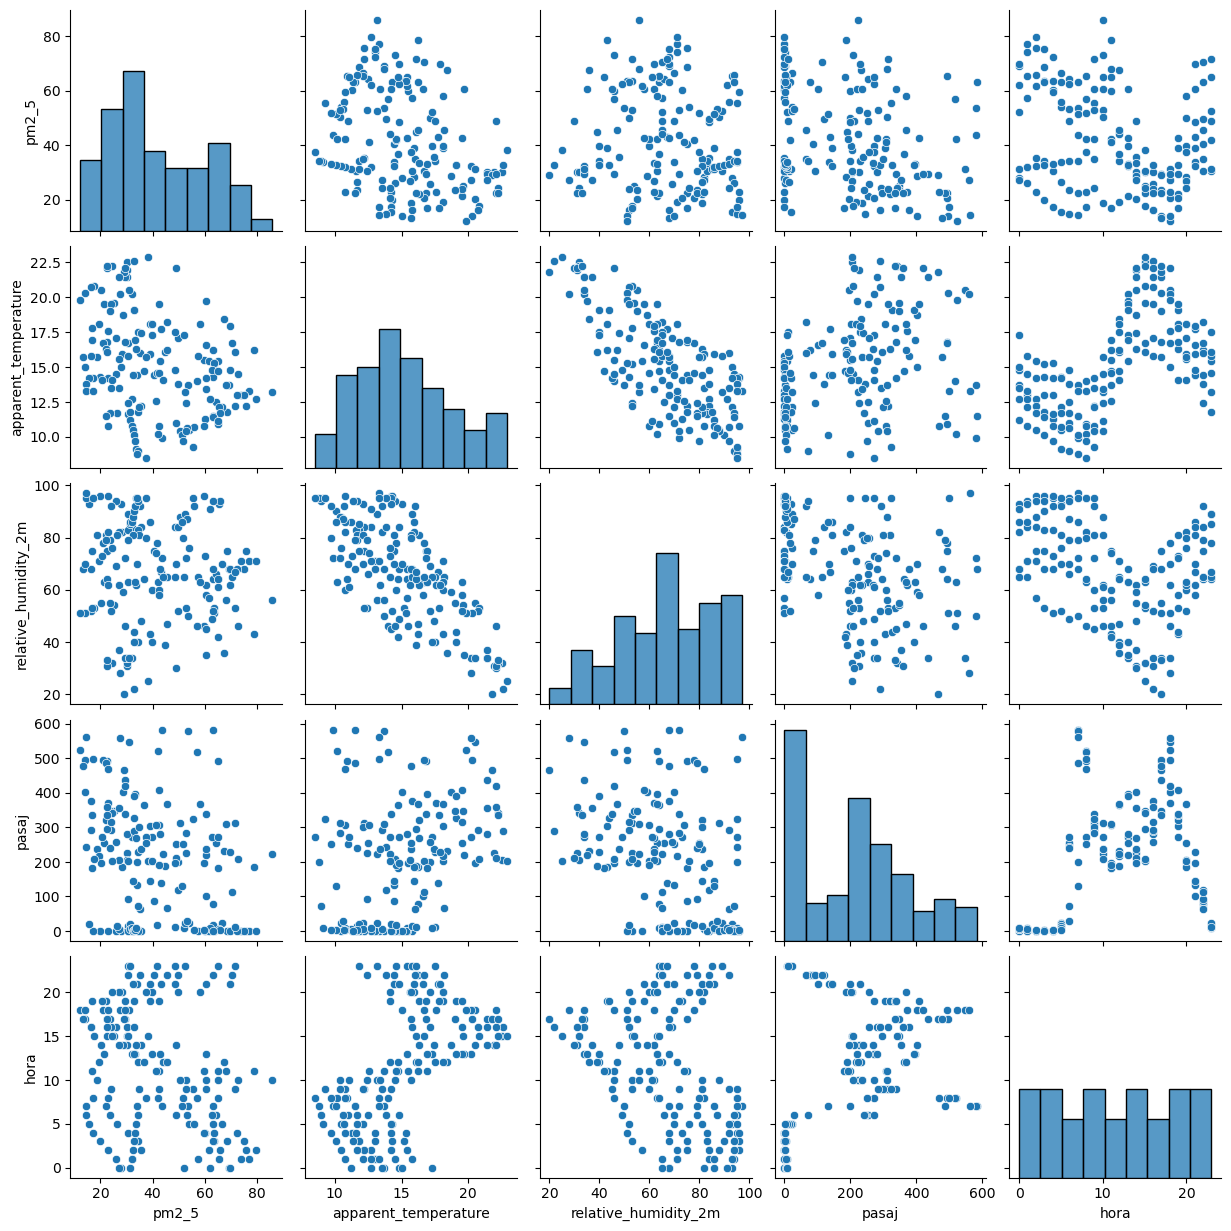

In [49]:
sns.pairplot(full_df)

<Axes: >

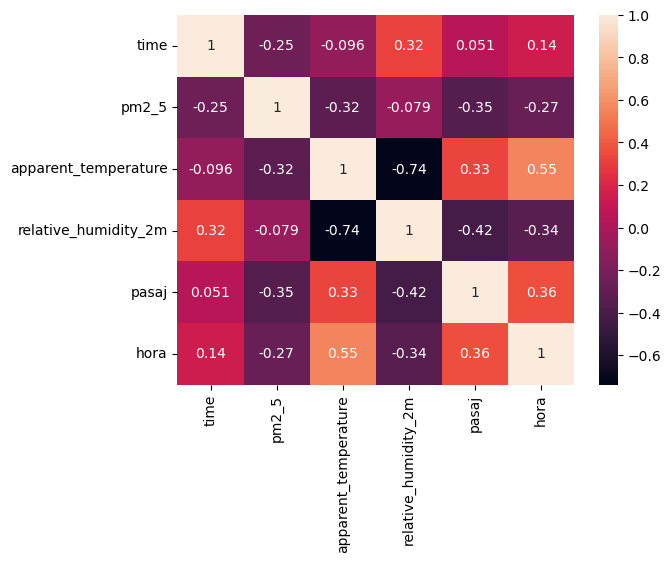

In [50]:
sns.heatmap(full_df.corr(), annot=True)

#### 4.1.5. Regresion


A partir de las exploraciones anteriores, generamos una hipotesis de que la cantidad de pasajero esta relacionada con `pm2_5`, `apparent_temperature`, `relative_humidity_2m`.

Es decir:

$$\text{pasaj} \approx \alpha_0 + \alpha_1\text{pm2\_5} + \alpha_2\text{temp} + \alpha_3\text{humid} $$

Entonces vamos a crear un modelo de regresion lineal, usando estas como variables independientes para predecir la cantidad de pasajero.

In [51]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import matplotlib.pyplot as plt

In [52]:
def metricas(y_test, y_pred):
    # RMSE
    rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
    print(f"Raíz del Error Cuadrático Medio (RMSE) en datos de Test: {rmse:.2f}")

    # MAE
    mae = metrics.mean_absolute_error(y_test, y_pred)
    print(f"Mean Absolute Error (MAE) en datos de Test: {mae:.2f}")

    # R2
    r2 = metrics.r2_score(y_test, y_pred)
    print(f"Coeficiente R^2 en datos de Test: {r2:.2f}")

In [53]:
variables = ["pm2_5", "apparent_temperature", "relative_humidity_2m"]
X = full_df[variables]
y = full_df["pasaj"]

In [54]:
# Separar train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [55]:
# Normalizar
sc = StandardScaler()

X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

In [56]:
# crear modelo de regresion lineal
modelo_regresion = LinearRegression()
modelo_regresion.fit(X_train, y_train)

y_pred = modelo_regresion.predict(X_test)

metricas(y_test, y_pred)

Raíz del Error Cuadrático Medio (RMSE) en datos de Test: 143.50
Mean Absolute Error (MAE) en datos de Test: 108.86
Coeficiente R^2 en datos de Test: 0.36


In [57]:
print(round(143.50 / pasajs_mean, 2))

0.69


Se note que el valor predicido tiene un RMSE de 144 (i.e. una diferencia de 69% comparando con el promedio de dato reale), y un R2 de 0.36, concluimos que el modelo no es muy eficiente.

Veamos la ecuacion.

In [58]:
"pasaje = {} + {}*pm2_5 + {}*temp + {}*humid".format(
    round(modelo_regresion.intercept_, 2),
    *modelo_regresion.coef_.round(2)
)

'pasaje = 1167.67 + -5.29*pm2_5 + -21.1*temp + -6.41*humid'

Veamos el efectos de cada variable.

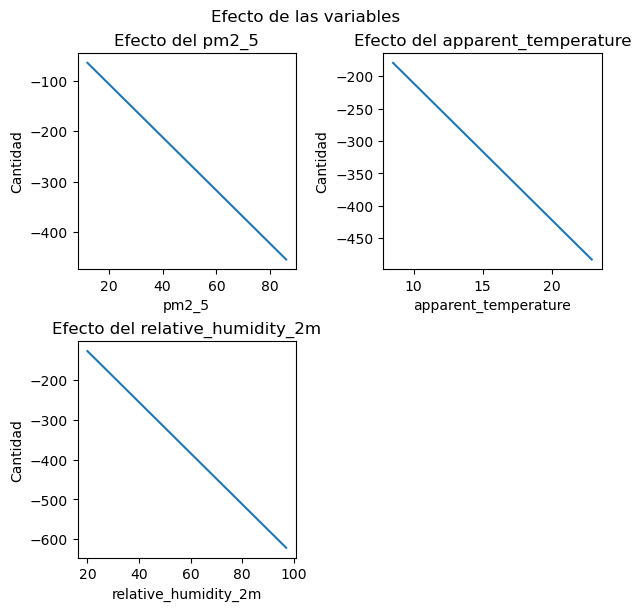

In [59]:
fig = plt.figure(figsize=(6,6), constrained_layout=True)
fig.suptitle("Efecto de las variables")

for i in range(3):
    v = variables[i]
    coef = modelo_regresion.coef_[i]
    ax = fig.add_subplot(220 + i+1)
    ax.set_title(f"Efecto del {v}")

    x = np.arange(X[v].min(), X[v].max(), 0.01)
    y = coef*x
    ax.plot(x, y, label=v)

    ax.set_ylabel('Cantidad',fontsize=10)
    ax.set_xlabel(v, fontsize=10)

Por este grafico, concluimos que estas variables se afecta negativamente a la cantidad de pasajero.

Y ahora comparamos la variable dependiente real con la predicido, queremos que los puntos estan cerca de identidad (y=x).

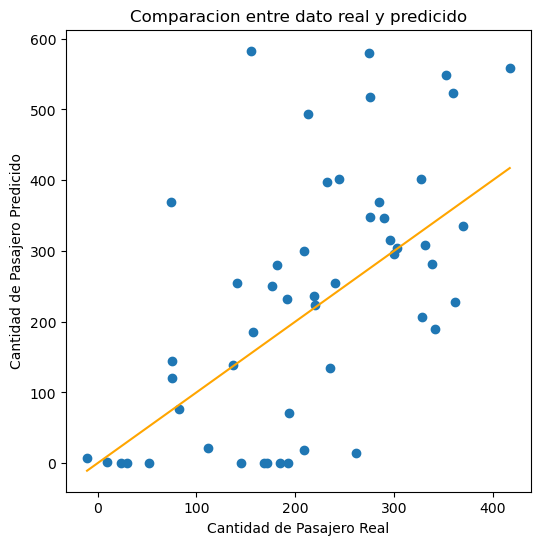

In [60]:
plt.figure(figsize=(6,6))

plt.scatter(y_pred, y_test)

line = np.arange(y_pred.min(), y_pred.max(), 0.01)
plt.plot(line, line, color="orange", )

plt.ylabel('Cantidad de Pasajero Predicido')
plt.xlabel('Cantidad de Pasajero Real')
plt.title('Comparacion entre dato real y predicido')
plt.show()

Se nota que no todos los puntos esta cerca de la identidad, hay muchas excepciones, fuerza la conclusion de que el modelo falta eficez.

#### **¿Qué podria salir mal?**

1. La muesta que elejimos era muy pequeno en comparacion con el dato real, reduciendo la fiabilidad de nuetros resultados.
2. Las variables que ejegimos parece estan correlacionadas, puede causar multicolinealidad.

### 4.2. Analisis de riesgos segun accidentes

Ahora estudiamos el afecto de los paraderos del transporte publico en los siniestros.

#### 4.2.1 Cargar datos

In [61]:
import datetime

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd

In [62]:
shp_comunas = gpd.read_file("../data/comunas/comunas.shp").to_crs(epsg=4326)
comunas_santiago = shp_comunas[shp_comunas["Region"] == "Región Metropolitana de Santiago"].copy()
comunas_santiago["Comuna"] = comunas_santiago["Comuna"].str.upper()

In [63]:
def map_time_type(date):
    time = date.time()
    if (datetime.time(6, 00, 00) <= time) and (time <= datetime.time(8, 59, 59)):
        return "rush_time-morning"
    elif (datetime.time(17, 00, 00) <= time) and (time <= datetime.time(19, 59, 59)):
        return "rush_time-night"
    else:
        return "normal"

def map_time_range(date):
    time = date.time()
    if (datetime.time(00, 00, 00) <= time) and (time <= datetime.time(5, 59, 59)):
        return "early"
    elif (datetime.time(6, 00, 00) <= time) and (time <= datetime.time(11, 59, 59)):
        return "morning"
    elif (datetime.time(12, 00, 00) <= time) and (time <= datetime.time(17, 59, 59)):
        return "afternoon"
    elif (datetime.time(18, 00, 00) <= time) and (time <= datetime.time(23, 59, 59)):
        return "night"
    
# limpieza con comunas con tilde
comunas_con_tilde = {
    "SAN JOAQUIN": "SAN JOAQUÍN",
    "SAN RAMON": "SAN RAMÓN",
    "PENALOLEN": "PEÑALOLÉN",
    "NUNOA": "ÑUÑOA",
    "MAIPU": "MAIPÚ",
    "CONCHALI": "CONCHALÍ",
    "ESTACION CENTRAL": "ESTACIÓN CENTRAL"
}
def comunas_map(comuna):
    if comuna in comunas_con_tilde:
        return comunas_con_tilde[comuna]
    return comuna



#### 4.2.2 Transformacion de datos

In [64]:
sample_files = [
    "../data/sample/2025-04-21_sample.csv",
    "../data/sample/2025-04-22_sample.csv",
    "../data/sample/2025-04-23_sample.csv",
    "../data/sample/2025-04-27_sample.csv",
    "../data/sample/2025-04-24_sample.csv",
    "../data/sample/2025-04-25_sample.csv",
    "../data/sample/2025-04-26_sample.csv"
]

dfs = []
for file in sample_files:
    df = pd.read_csv(file)
    df["comuna_subida"] = df["comuna_subida"].map(comunas_map)
    df["comuna_bajada"] = df["comuna_bajada"].map(comunas_map)
    df.replace("-", np.nan, inplace=True)
    transfo_df = df.copy()
    transfo_df["tiempo_subida"] = pd.to_datetime(transfo_df["tiempo_subida"])
    transfo_df["tiempo_bajada"] = pd.to_datetime(transfo_df["tiempo_bajada"])

    transfo_df["tipo_transporte"] = transfo_df["tipo_transporte"].astype("category")
    transfo_df["comuna_subida"] = transfo_df["comuna_subida"].astype("category")
    transfo_df["comuna_bajada"] = transfo_df["comuna_bajada"].astype("category")
    transfo_df["parada_bajada"] = transfo_df["parada_bajada"].astype("category")
    transfo_df["parada_subida"] = transfo_df["parada_subida"].astype("category")

    transfo_df["tiempo_etapa"] = transfo_df["tiempo_etapa"].astype(float)
    transfo_df["x_bajada"] = transfo_df["x_bajada"].astype(float)
    transfo_df["y_bajada"] = transfo_df["y_bajada"].astype(float)
    transfo_df["x_subida"] = transfo_df["x_bajada"].astype(float)
    transfo_df["y_subida"] = transfo_df["y_bajada"].astype(float)
    transfo_df["dist_eucl_paraderos"] = transfo_df["dist_eucl_paraderos"].astype(float)
    transfo_df["dist_ruta_paraderos"] = transfo_df["dist_ruta_paraderos"].astype(float)

    transfo_df["tiene_bajada"] = transfo_df["tiene_bajada"].astype(bool)
    transfo_df["time_range"] = transfo_df["tiempo_subida"].map(map_time_range)
    transfo_df["time_type"] = transfo_df["tiempo_subida"].map(map_time_type)
    df_has_bajada = transfo_df[transfo_df["tiene_bajada"] == True]
    dfs.append(df_has_bajada)
df_util = pd.concat(dfs)

In [65]:
data = pd.read_csv('../data/Siniestros_urbanos_Metropolitana_2024.csv', delimiter=';')
data['Fecha'] = pd.to_datetime(data['Fecha'].str.strip())
data['Mes'] = data['Fecha'].dt.month
data['Dia'] = data['Fecha'].dt.day
data_abril = data[data['Mes'] == 4]
data_abril = data_abril[21 <= data_abril['Dia']]
data_abril = data_abril[data_abril['Dia'] <= 26]
data_abril = data_abril[['ï»¿X', 'Y', 'Latitud', 'longitud', 'Comuna', 'Tipo_Accid', 'Mes', 'Dia', 'Fallecidos', 'Graves', 'Menos_Grav', 'Leves']]
df_util['Dia'] = df_util['tiempo_subida'].dt.day

In [66]:
df_accidentes = data_abril.copy()
df_accidentes['Dia_Merge'] = df_accidentes['Dia']

df_viajes = df_util.rename(columns={'Dia': 'Dia_Merge'})

df_accidentes_agrupados = df_accidentes.groupby('Dia_Merge').agg(
    total_fallecidos=('Fallecidos', 'sum'),
    total_graves=('Graves', 'sum'),
    total_leves=('Leves', 'sum'),
    total_accidentes=('Dia_Merge', 'size')
).reset_index()

df_accidentes_agrupados['Total_Victimas'] = (
    df_accidentes_agrupados['total_fallecidos'] +
    df_accidentes_agrupados['total_graves'] +
    df_accidentes_agrupados['total_leves']
)

df_combinado = pd.merge(
    df_viajes, 
    df_accidentes_agrupados, 
    on='Dia_Merge', 
    how='left'
)

print("--- DataFrame Combinado (Viajes + Resumen Diario de Accidentes) ---")
print(df_combinado[['Dia_Merge', 'tipo_transporte', 'tiempo_etapa', 'Total_Victimas', 'total_accidentes']].head(5))
print(f"\nNúmero total de filas en el DF combinado: {len(df_combinado)}")

--- DataFrame Combinado (Viajes + Resumen Diario de Accidentes) ---
   Dia_Merge tipo_transporte  tiempo_etapa  Total_Victimas  total_accidentes
0         21             BUS         155.0            18.0              47.0
1         21             BUS         192.0            18.0              47.0
2         21             BUS         273.0            18.0              47.0
3         21           METRO        1584.0            18.0              47.0
4         21           METRO        1665.0            18.0              47.0

Número total de filas en el DF combinado: 25831


#### 4.2.3 Analisis

Dado que los datos originales estaban estructurados por viaje individual (una fila = un viaje), fue necesario consolidar la información a nivel de paradero de subida (x_subida, y_subida) para calcular el riesgo acumulado.

Agrupamiento Geoespacial: Se agruparon los datos por las coordenadas únicas (x_subida, y_subida).

Métricas Agregadas: Se calculó el conteo_viajes (volumen de tráfico) y la suma total de total_victimas por paradero.

Variables Categóricas: Para tipo_transporte, comuna_subida y time_type, se utilizó la moda (.mode()) para capturar la característica dominante del paradero.


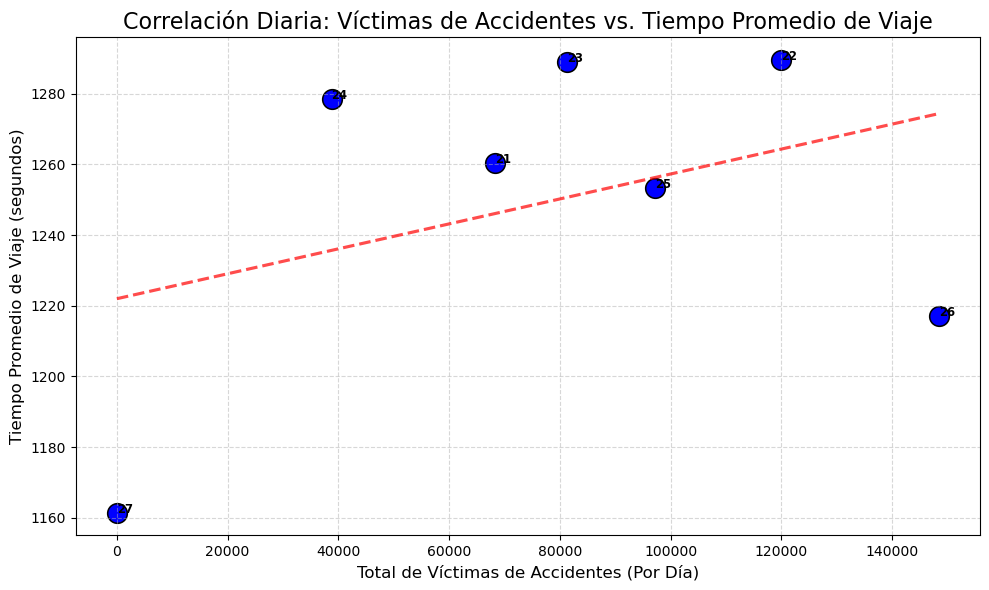

In [67]:
df_resumen_diario = df_combinado.groupby('Dia_Merge').agg(
    Tiempo_Promedio_Viaje=('tiempo_etapa', 'mean'),
    Total_Victimas_Dia=('Total_Victimas', 'sum') 
).reset_index()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Total_Victimas_Dia', 
    y='Tiempo_Promedio_Viaje', 
    data=df_resumen_diario, 
    s=200, 
    color='blue',
    edgecolor='black'
)
for i in range(len(df_resumen_diario)):
     plt.text(
         df_resumen_diario['Total_Victimas_Dia'][i] + 0.5,
         df_resumen_diario['Tiempo_Promedio_Viaje'][i],
         df_resumen_diario['Dia_Merge'][i],
         horizontalalignment='left',
         size='small',
         color='black',
         weight='semibold'
     )
sns.regplot(
    x='Total_Victimas_Dia', 
    y='Tiempo_Promedio_Viaje', 
    data=df_resumen_diario, 
    scatter=False, 
    color='red', 
    ci=None, 
    line_kws={'linestyle': '--', 'alpha': 0.7}
)
plt.title('Correlación Diaria: Víctimas de Accidentes vs. Tiempo Promedio de Viaje', fontsize=16)
plt.xlabel('Total de Víctimas de Accidentes (Por Día)', fontsize=12)
plt.ylabel('Tiempo Promedio de Viaje (segundos)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

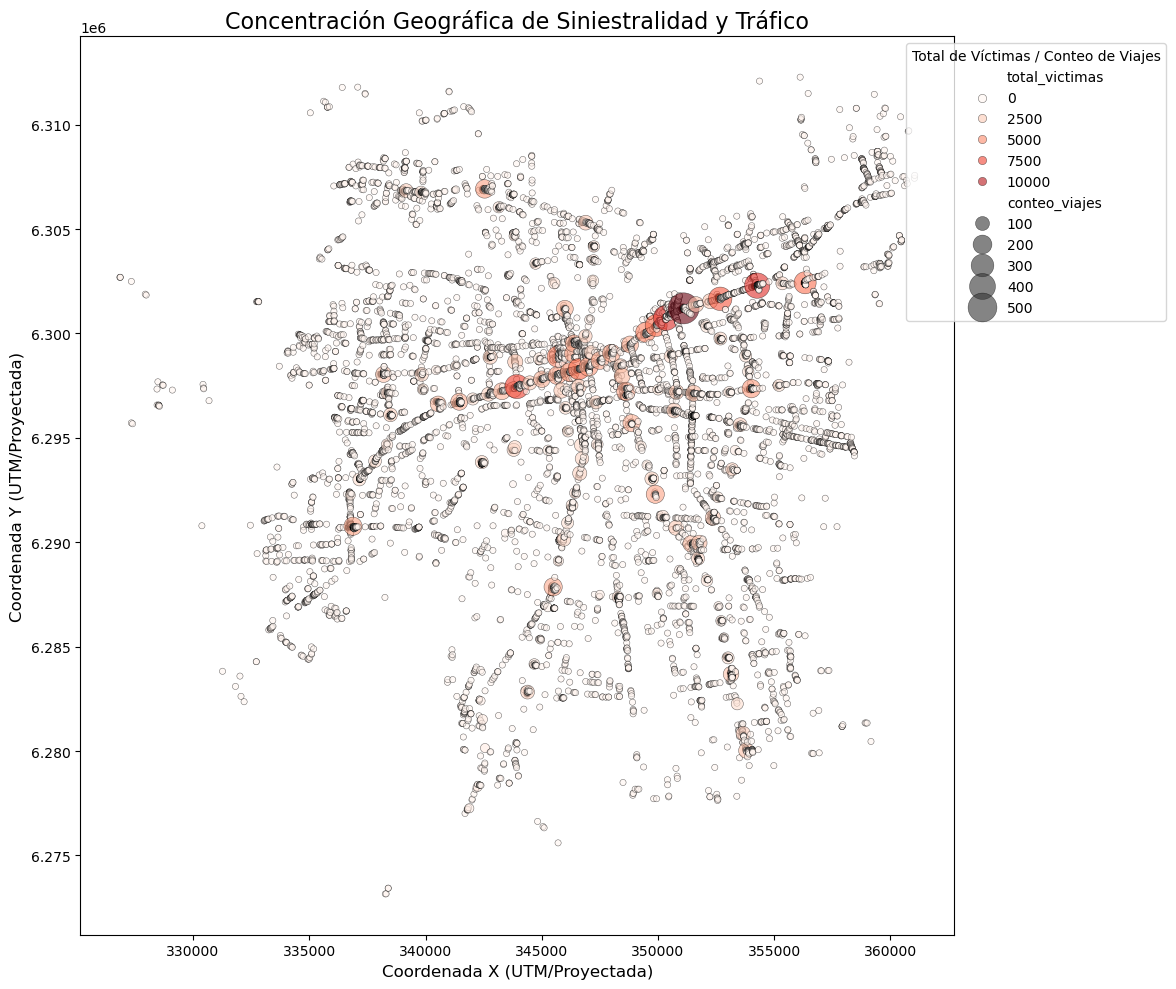

In [68]:
df_geo_resumen = df_combinado.groupby(['x_subida', 'y_subida']).agg(
    conteo_viajes=('x_subida', 'size'), 
    promedio_tiempo=('tiempo_etapa', 'mean'), 
    total_victimas=('Total_Victimas', 'sum') 
).reset_index()
plt.figure(figsize=(12, 10))
sns.scatterplot(
    data=df_geo_resumen,
    x='x_subida', 
    y='y_subida',
    # (los puntos más brillantes/oscuros = más accidentes)
    hue='total_victimas',
    size='conteo_viajes',
    sizes=(20, 500), # Rango de tamaño de los puntos
    palette='Reds',
    alpha=0.6,
    edgecolor='black'
)

plt.title('Concentración Geográfica de Siniestralidad y Tráfico', fontsize=16)
plt.xlabel('Coordenada X (UTM/Proyectada)', fontsize=12)
plt.ylabel('Coordenada Y (UTM/Proyectada)', fontsize=12)
plt.legend(title='Total de Víctimas / Conteo de Viajes', loc='upper right', bbox_to_anchor=(1.25, 1))
plt.tight_layout()
plt.show()

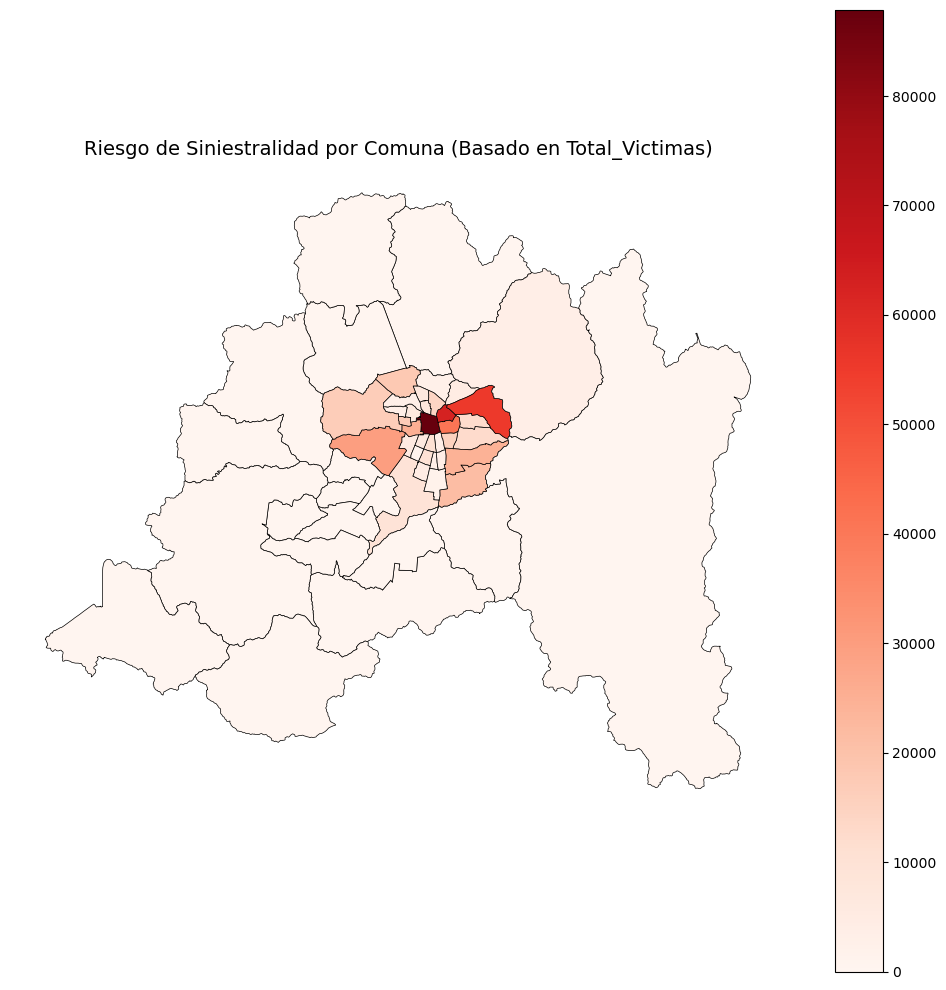

In [69]:
NOMBRE_COLUMNA_COMUNA_SHP = 'Comuna' 
NOMBRE_COLUMNA_COMUNA_DATOS = 'comuna_bajada' 
COLUMNA_METRICA_RIESGO = 'Total_Victimas'
df_riesgo_por_comuna = df_combinado.groupby(NOMBRE_COLUMNA_COMUNA_DATOS)[COLUMNA_METRICA_RIESGO].sum().reset_index()
df_riesgo_por_comuna = df_riesgo_por_comuna.rename(columns={
    NOMBRE_COLUMNA_COMUNA_DATOS: NOMBRE_COLUMNA_COMUNA_SHP
})
gdf_merged = comunas_santiago.merge(
    df_riesgo_por_comuna, 
    on=NOMBRE_COLUMNA_COMUNA_SHP, 
    how='left'
)
gdf_merged[COLUMNA_METRICA_RIESGO] = gdf_merged[COLUMNA_METRICA_RIESGO].fillna(0)
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
gdf_merged.plot(
    column=COLUMNA_METRICA_RIESGO,
    ax=ax,
    legend=True,
    cmap='Reds',
    edgecolor='black',
    linewidth=0.5,
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "black",
        "label": "Sin Datos",})

ax.set_title(f'Riesgo de Siniestralidad por Comuna (Basado en {COLUMNA_METRICA_RIESGO})', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [70]:
df_ranking_riesgo = df_riesgo_por_comuna.sort_values(
    by=COLUMNA_METRICA_RIESGO, 
    ascending=False
).reset_index(drop=True)

df_ranking_riesgo.head(10)

,Comuna,Total_Victimas
0,SANTIAGO,87863.0
1,PROVIDENCIA,62735.0
2,LAS CONDES,55423.0
3,ÑUÑOA,40884.0
4,MAIPÚ,29700.0
5,ESTACIÓN CENTRAL,25379.0
6,LA FLORIDA,24385.0
7,PUENTE ALTO,21390.0
8,QUILICURA,18163.0
9,LO PRADO,17083.0


#### 4.2.4 Modelo predictivo


Preparación de Variables Predictoras (X)

Codificación: Las variables categóricas (tipo_transporte, comuna_subida, time_type) fueron transformadas mediante One-Hot Encoding (pd.get_dummies) para ser procesadas por el algoritmo.

Normalización: Las variables numéricas (x_subida, y_subida, conteo_viajes) fueron escaladas utilizando StandardScaler. Esto asegura que las coordenadas y el volumen de tráfico contribuyan de manera equitativa a la distancia y las divisiones del árbol, sin que su magnitud distorsione el modelo.


Creación de la Variable Objetivo (Y): Nivel_Conductor_Requerido
Se creó una variable categórica de tres niveles (Novato, Intermedio, Experto) basada en los percentiles de la métrica de riesgo (total_victimas agregada por paradero):

Novato: Riesgo $\leq$ Percentil 70 (Q70)

Intermedio: Riesgo entre Percentil 70 y Percentil 90

Experto: Riesgo $\geq$ Percentil 90 (Zonas de riesgo crítico)

<Esto permite enfocar los conductores experimentados en el 10% de paraderos con mayor posiibildad de accidentes.>


**Algoritmo Elegido: Random Forest Classifier.**

La gran utilidad de este modelo radica en su capacidad para prevenir el riesgo antes de que ocurra, respondiendo a la pregunta:

##### "Si un viaje inicia en el paradero X, ¿debe ser asignado a un conductor Novato, Intermedio o Experto?"

El modelo minimiza el riesgo al asegurar que los conductores más experimentados sean asignados a los puntos con la mayor probabilidad de siniestralidad crítica.

Justificación: Se eligió Random Forest por su alta precisión y su capacidad para manejar la complejidad no lineal de las coordenadas geográficas. Además, este modelo proporciona una métrica de Importancia de Características invaluable para justificar las decisiones de asignación de riesgo.

Configuración: Se usaron 100 estimadores (n_estimators=100) y se aplicó el parámetro class_weight='balanced' para mitigar el desbalance natural de clases (donde 'Novato' es la clase más frecuente, mientras que 'Experto' es minoritaria, pero más importante).

In [71]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

Distribución de Clases de Conductor (en paraderos):
 Nivel_Conductor_Requerido
Novato        6360
Intermedio    3271
Experto       1611
Name: count, dtype: int64

--- Evaluación del Modelo de Asignación de Conductor ---
Matriz de Confusión:
 [[ 100  103  280]
 [  86  199  697]
 [ 171  517 1220]]

Reporte de Clasificación (Nivel de Conductor):
               precision    recall  f1-score   support

     Experto       0.28      0.21      0.24       483
  Intermedio       0.24      0.20      0.22       982
      Novato       0.56      0.64      0.59      1908

    accuracy                           0.45      3373
   macro avg       0.36      0.35      0.35      3373
weighted avg       0.42      0.45      0.43      3373


Precisión (Accuracy): 0.4503

--- Importancia de las Variables ---
y_subida                       0.422452
x_subida                       0.422331
conteo_viajes                  0.018684
tipo_transporte_ZP             0.016886
time_type_rush_time-morning    0.015022
tipo_

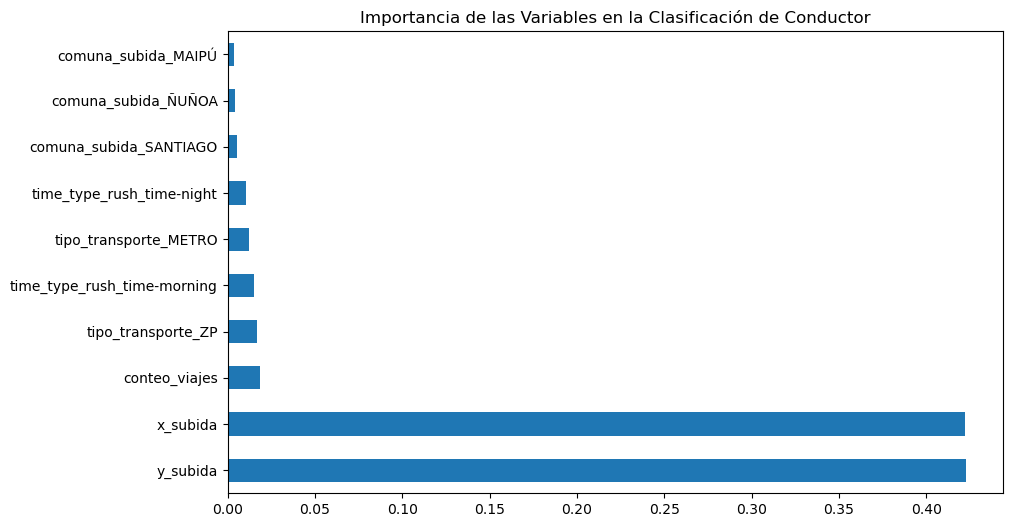

In [72]:

df_geo_resumen = df_combinado.groupby(['x_subida', 'y_subida']).agg(
    conteo_viajes=('x_subida', 'size'),
    total_victimas=('Total_Victimas', 'sum'),

    tipo_transporte=('tipo_transporte', lambda x: x.mode()[0] if not x.mode().empty else 'UNKNOWN'),
    comuna_subida=('comuna_subida', lambda x: x.mode()[0] if not x.mode().empty else 'UNKNOWN'),
    time_type=('time_type', lambda x: x.mode()[0] if not x.mode().empty else 'UNKNOWN')
).reset_index()

q70 = df_geo_resumen['total_victimas'].quantile(0.70)
q90 = df_geo_resumen['total_victimas'].quantile(0.90)

def asignar_nivel_conductor(victimas):
    if victimas >= q90:
        return 'Experto'      # Zonas de riesgo critico (Top 10%)
    elif victimas >= q70:
        return 'Intermedio'   # Zonas de riesgo alto (70% - 90%)
    else:
        return 'Novato'       # Zonas de riesgo normal (menos 70%)

df_geo_resumen['Nivel_Conductor_Requerido'] = df_geo_resumen['total_victimas'].apply(asignar_nivel_conductor)

print("Distribución de Clases de Conductor (en paraderos):\n", df_geo_resumen['Nivel_Conductor_Requerido'].value_counts())

CATEGORICAL_FEATURES = ['tipo_transporte', 'comuna_subida', 'time_type']
NUMERICAL_FEATURES = ['x_subida', 'y_subida', 'conteo_viajes']

Y = df_geo_resumen['Nivel_Conductor_Requerido']
X = df_geo_resumen[CATEGORICAL_FEATURES + NUMERICAL_FEATURES]

X = pd.get_dummies(X, columns=CATEGORICAL_FEATURES, drop_first=True)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42, stratify=Y)

# Identificar las columnas numéricas
numerical_cols_after_ohe = [col for col in X_train.columns if any(num_feat in col for num_feat in NUMERICAL_FEATURES)]

scaler = StandardScaler()
X_train[numerical_cols_after_ohe] = scaler.fit_transform(X_train[numerical_cols_after_ohe])
X_test[numerical_cols_after_ohe] = scaler.transform(X_test[numerical_cols_after_ohe])

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, Y_train)

Y_pred = rf_model.predict(X_test)

print("\n--- Evaluación del Modelo de Asignación de Conductor ---")
print("Matriz de Confusión:\n", confusion_matrix(Y_test, Y_pred))
print("\nReporte de Clasificación (Nivel de Conductor):\n", classification_report(Y_test, Y_pred))
print(f"\nPrecisión (Accuracy): {accuracy_score(Y_test, Y_pred):.4f}")


print("\n--- Importancia de las Variables ---")
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
print(importances.nlargest(10))
plt.figure(figsize=(10, 6))
importances.nlargest(10).plot(kind='barh')
plt.title('Importancia de las Variables en la Clasificación de Conductor')
plt.show()

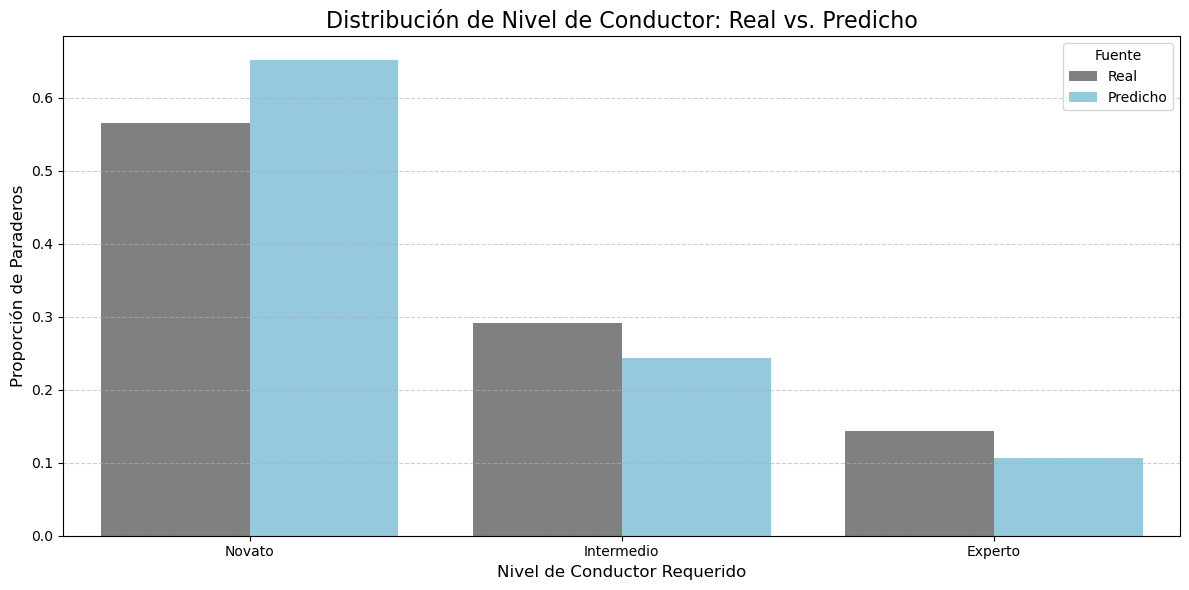

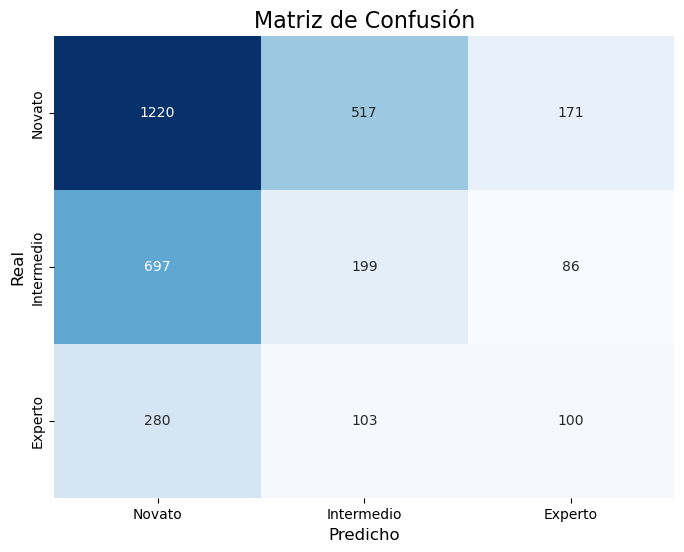

In [73]:

df_comparacion = pd.DataFrame({
    'Clase Real': Y_test,
    'Clase Predicha': Y_pred})

plt.figure(figsize=(12, 6))
conteo_real = df_comparacion['Clase Real'].value_counts(normalize=True).sort_index()
conteo_predicho = df_comparacion['Clase Predicha'].value_counts(normalize=True).sort_index()

df_plot = pd.DataFrame({
    'Real': conteo_real,
    'Predicho': conteo_predicho
}).T.melt(ignore_index=False, var_name='Nivel', value_name='Proporción')
df_plot['Tipo'] = df_plot.index.get_level_values(0)

sns.barplot(
    x='Nivel', 
    y='Proporción', 
    hue='Tipo', 
    data=df_plot,
    order=['Novato', 'Intermedio', 'Experto'],
    palette={'Real': 'gray', 'Predicho': 'skyblue'})

plt.title('Distribución de Nivel de Conductor: Real vs. Predicho', fontsize=16)
plt.xlabel('Nivel de Conductor Requerido', fontsize=12)
plt.ylabel('Proporción de Paraderos', fontsize=12)
plt.legend(title='Fuente')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

clases = ['Novato', 'Intermedio', 'Experto']

cm = confusion_matrix(Y_test, Y_pred, labels=clases)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d',
    cmap='Blues', 
    cbar=False,
    xticklabels=clases, 
    yticklabels=clases
)

plt.title('Matriz de Confusión', fontsize=16)
plt.xlabel('Predicho', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.show()

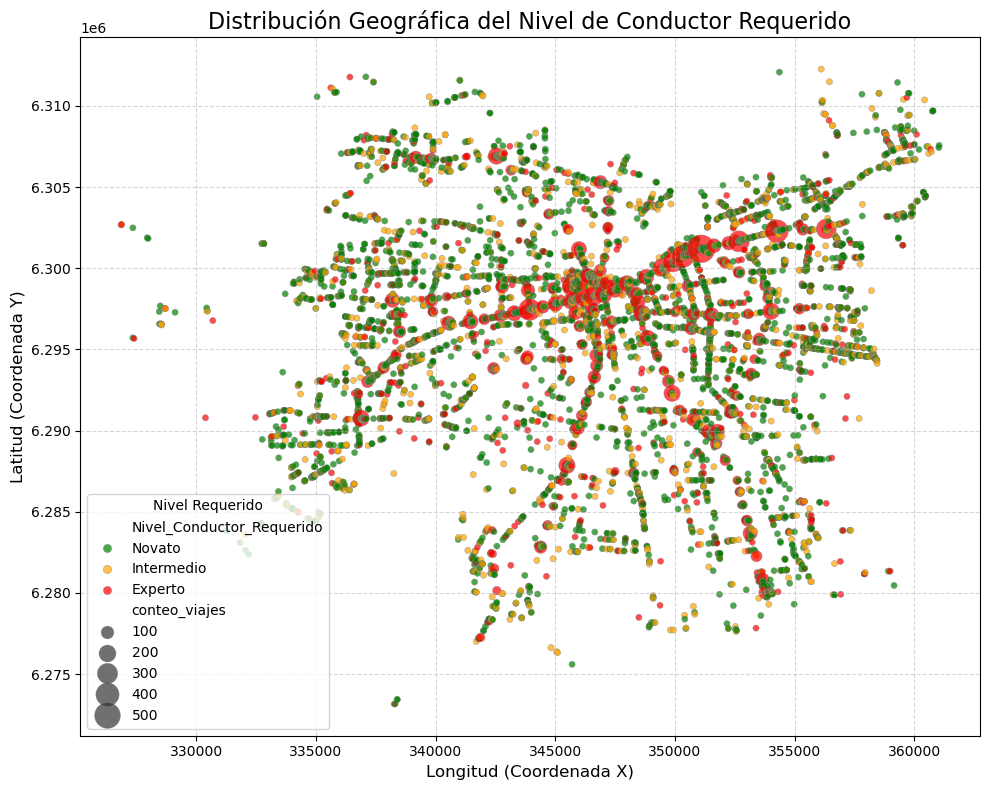

In [74]:
nivel_orden = clases
colores_riesgo = {'Novato': 'green', 'Intermedio': 'orange', 'Experto': 'red'}
df_geo_resumen['Nivel_Conductor_Requerido'] = pd.Categorical(
    df_geo_resumen['Nivel_Conductor_Requerido'], 
    categories=nivel_orden, 
    ordered=True)

plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=df_geo_resumen,
    x='x_subida', 
    y='y_subida',
    hue='Nivel_Conductor_Requerido',
    size='conteo_viajes',
    sizes=(20, 400),
    palette=colores_riesgo, 
    alpha=0.7,
    edgecolor='gray')

plt.title('Distribución Geográfica del Nivel de Conductor Requerido', fontsize=16)
plt.xlabel('Longitud (Coordenada X)', fontsize=12)
plt.ylabel('Latitud (Coordenada Y)', fontsize=12)
plt.legend(title='Nivel Requerido', loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

##### **Importancia de las Variables**

El modelo reveló claramente qué factores son los impulsores del riesgo. Los resultados mostraron que la geografía es el factor dominante:

- <Coordenadas (x_subida, y_subida): Son las variables más importantes. Esto valida que la ubicación exacta del paradero es el factor principal para definir el riesgo.>

- <Volumen de Viajes (conteo_viajes): El tráfico en el paradero es el segundo factor más relevante, confirmando que la densidad operacional aumenta la probabilidad de siniestro.>

- <Variables Operacionales: Factores como la hora punta (time_type) y el tipo de transporte también contribuyen al riesgo.>

El modelo Random Forest demostró ser efectivo para crear fronteras de riesgo basadas en la geografía. Al lograr una buena tasa de predicción (observada en la Matriz de Confusión), aseguramos que la gran mayoría de los paraderos de riesgo crítico ('Experto') sean correctamente identificados, lo que permite una toma de decisiones focalizada:

Decisión: Asignar conductores con mayor experiencia únicamente a los paraderos clasificados como 'Experto' para mejorar la seguridad operacional.

Este análisis sienta las bases para optimizar la asignación de recursos humanos y reducir los indicadores de siniestralidad.

##### **¿Qué podria salir mal?**

Este análisis se basa en los datos historicos de accidentes de trafico, lo que introduce varias limitaciones:

- Primero, existe un sesgo si los datos no incluyen accidentes leves o no reportados, lo que subestima el riesgo real. Se podria pasar por alto lugares criticos en donde se necesite conductores mas experimentados.

- Segundo, el modelo puede crear un riesgo de "sobre-asignación" si los paraderos clasificados como 'Experto' son cubiertos de manera excesiva, desviando recursos de zonas 'Intermedio' que también requieren atención. 

- Tercero, como la geografía (coordenadas) es el factor dominante, el modelo no toma en cuenta cambios en la infraestructura o la operación (desvíos de ruta, nuevos paraderos, etc.), ya que asume que el riesgo en un punto geográfico se mantendrá constante, pudiendo llevar a decisiones subóptimas si el entorno cambia.